In [2]:
import pandas as pd
from sklearn.utils import resample

In [3]:
samm_data =pd.read_csv("E:/GNN/data/sammassamexpression/eda.csv")
ck_data = pd.read_csv("E:/GNN/data/ckplusferdata/eda.csv")
casme2_data = pd.read_csv("E:/GNN/data/casme2-preprocessed-v2/eda.csv")

In [4]:
print("Samm Dataset Class Distribution:")
samm_data['class'].value_counts()

Samm Dataset Class Distribution:


class
happy      10001
neutral     4815
fear        2954
angry       2940
sad         2855
Name: count, dtype: int64

In [5]:
print("CK+ Dataset Class Distribution:")
ck_data['class'].value_counts()


CK+ Dataset Class Distribution:


class
happy       8989
neutral     6198
sad         6077
fear        5121
angry       4953
surprise    4002
disgust      547
Name: count, dtype: int64

In [6]:
print("CASME2 Dataset Class Distribution:")
casme2_data['class'].value_counts()


CASME2 Dataset Class Distribution:


class
others        6344
disgust       4159
happiness     2360
repression    2178
surprise      1577
sadness        274
fear           127
Name: count, dtype: int64

In [7]:
casme2_data['filepath'] = casme2_data['filepath'].apply(lambda x: x.replace('\\', '/'))
samm_data['filepath'] = samm_data['filepath'].apply(lambda x: x.replace('\\', '/'))
ck_data['filepath'] = ck_data['filepath'].apply(lambda x: x.replace('\\', '/'))
casme2_data['filepath'] = casme2_data['filepath'].apply(lambda x: x.replace('\\', '/'))
u_ck = ck_data['class'].unique()
u_samm = samm_data['class'].unique()
u_casme2 = casme2_data['class'].unique()


In [8]:
u_samm

<ArrowStringArray>
['angry', 'fear', 'happy', 'neutral', 'sad']
Length: 5, dtype: str

In [9]:

u_ck

<ArrowStringArray>
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Length: 7, dtype: str

In [10]:
casme2_data['class'] = casme2_data['class'].replace({
    'repression': 'angry', 
    'disgust':'disgust',
    'fear': 'fear',
    'happiness': 'happy',
    'others': 'neutral',
    'sadness': 'sad',
    'surprise': 'surprise'
    })

In [11]:
print("need to middle Sample")
casme2_data['class'].value_counts() 


need to middle Sample


class
neutral     6344
disgust     4159
happy       2360
angry       2178
surprise    1577
sad          274
fear         127
Name: count, dtype: int64

In [12]:
print("need to middle Sample")
ck_data['class'].value_counts()

need to middle Sample


class
happy       8989
neutral     6198
sad         6077
fear        5121
angry       4953
surprise    4002
disgust      547
Name: count, dtype: int64

In [13]:
print("need to under Sample")
samm_data['class'].value_counts()

need to under Sample


class
happy      10001
neutral     4815
fear        2954
angry       2940
sad         2855
Name: count, dtype: int64

In [14]:
def oversample_dataset(df,label_column="class",random_state=42,shuffle=True):
    """
    Oversample all classes to the size of the largest class.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    label_column : str
        Target column.

    random_state : int
        Random seed.

    shuffle : bool
        Shuffle the final dataframe.

    Returns
    -------
    balanced_df : pandas.DataFrame
        Oversampled dataframe.
    """

    # Class distribution
    class_counts = df[label_column].value_counts().sort_index()

    print("=" * 70)
    print("ORIGINAL CLASS DISTRIBUTION")
    print("=" * 70)
    print(class_counts)

    # Maximum Sample Size
    target_size = class_counts.max()

    print("\nTarget Sample Size (Maximum):", target_size)
    print("=" * 70)

    balanced_data = []

    for class_name, count in class_counts.items():

        class_df = df[df[label_column] == class_name]

        if count < target_size:
            class_df = resample(
                class_df,
                replace=True,
                n_samples=target_size,
                random_state=random_state
            )

        balanced_data.append(class_df)

    balanced_df = pd.concat(balanced_data)

    if shuffle:
        balanced_df = balanced_df.sample(
            frac=1,
            random_state=random_state
        ).reset_index(drop=True)

    print("OVERSAMPLED CLASS DISTRIBUTION")
    print("=" * 70)
    print(balanced_df[label_column].value_counts().sort_index())

    print("\nBalanced Dataset Shape:", balanced_df.shape)

    return balanced_df

In [15]:
def balance_to_middle_sample(df, label_column="class",random_state=42,shuffle=True):
    """
    Balance dataset to the median (middle) class size.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    label_column : str
        Name of the target column.

    random_state : int
        Random seed.

    shuffle : bool
        Shuffle the final dataframe.

    Returns
    -------
    balanced_df : pandas.DataFrame
        Balanced dataframe.
    """

    # Class distribution
    class_counts = df[label_column].value_counts().sort_index()

    print("=" * 70)
    print("ORIGINAL CLASS DISTRIBUTION")
    print("=" * 70)
    print(class_counts)

    # Middle Sample Size (Median)
    middle_sample = int(class_counts.median())

    print("\nMiddle Sample Size:", middle_sample)
    print("=" * 70)

    balanced_data = []

    for class_name, count in class_counts.items():

        class_df = df[df[label_column] == class_name]

        if count > middle_sample:
            # Undersampling
            class_df = resample(
                class_df,
                replace=False,
                n_samples=middle_sample,
                random_state=random_state
            )

        elif count < middle_sample:
            # Oversampling
            class_df = resample(
                class_df,
                replace=True,
                n_samples=middle_sample,
                random_state=random_state
            )

        balanced_data.append(class_df)

    balanced_df = pd.concat(balanced_data)

    if shuffle:
        balanced_df = balanced_df.sample(frac=1,random_state=random_state).reset_index(drop=True)

    print("BALANCED CLASS DISTRIBUTION")
    print("=" * 70)
    print(balanced_df[label_column].value_counts().sort_index())

    print("\nBalanced Dataset Shape:", balanced_df.shape)

    return balanced_df

In [16]:
def undersample_dataset(df,label_column="class",random_state=42,shuffle=True):
    """
    Undersample all classes to the size of the smallest class.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    label_column : str
        Target column.

    random_state : int
        Random seed.

    shuffle : bool
        Shuffle the final dataframe.

    Returns
    -------
    balanced_df : pandas.DataFrame
        Undersampled dataframe.
    """

    # Class distribution
    class_counts = df[label_column].value_counts().sort_index()

    print("=" * 70)
    print("ORIGINAL CLASS DISTRIBUTION")
    print("=" * 70)
    print(class_counts)

    # Minimum Sample Size
    target_size = class_counts.min()

    print("\nTarget Sample Size (Minimum):", target_size)
    print("=" * 70)

    balanced_data = []

    for class_name, count in class_counts.items():

        class_df = df[df[label_column] == class_name]

        if count > target_size:
            class_df = resample(
                class_df,
                replace=False,
                n_samples=target_size,
                random_state=random_state
            )

        balanced_data.append(class_df)

    balanced_df = pd.concat(balanced_data)

    if shuffle:
        balanced_df = balanced_df.sample(
            frac=1,
            random_state=random_state
        ).reset_index(drop=True)

    print("UNDERSAMPLED CLASS DISTRIBUTION")
    print("=" * 70)
    print(balanced_df[label_column].value_counts().sort_index())

    print("\nBalanced Dataset Shape:", balanced_df.shape)

    return balanced_df

In [17]:
balanced_oversample_casme2 = oversample_dataset(casme2_data,label_column="class")
balanced_middle_casme2 = balance_to_middle_sample(casme2_data,label_column="class")
balanced_undersample_casme2 = undersample_dataset(casme2_data,label_column="class")

ORIGINAL CLASS DISTRIBUTION
class
angry       2178
disgust     4159
fear         127
happy       2360
neutral     6344
sad          274
surprise    1577
Name: count, dtype: int64

Target Sample Size (Maximum): 6344
OVERSAMPLED CLASS DISTRIBUTION
class
angry       6344
disgust     6344
fear        6344
happy       6344
neutral     6344
sad         6344
surprise    6344
Name: count, dtype: int64

Balanced Dataset Shape: (44408, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       2178
disgust     4159
fear         127
happy       2360
neutral     6344
sad          274
surprise    1577
Name: count, dtype: int64

Middle Sample Size: 2178
BALANCED CLASS DISTRIBUTION
class
angry       2178
disgust     2178
fear        2178
happy       2178
neutral     2178
sad         2178
surprise    2178
Name: count, dtype: int64

Balanced Dataset Shape: (15246, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       2178
disgust     4159
fear         127
happy       2360
neutral     6344
sad          274
surprise 

In [18]:
balanced_oversample_ck = oversample_dataset(ck_data,label_column="class")
balanced_middle_ck = balance_to_middle_sample(ck_data,label_column="class")
balanced_undersample_ck = undersample_dataset(ck_data,label_column="class")

ORIGINAL CLASS DISTRIBUTION
class
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64

Target Sample Size (Maximum): 8989
OVERSAMPLED CLASS DISTRIBUTION
class
angry       8989
disgust     8989
fear        8989
happy       8989
neutral     8989
sad         8989
surprise    8989
Name: count, dtype: int64

Balanced Dataset Shape: (62923, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64

Middle Sample Size: 5121
BALANCED CLASS DISTRIBUTION
class
angry       5121
disgust     5121
fear        5121
happy       5121
neutral     5121
sad         5121
surprise    5121
Name: count, dtype: int64

Balanced Dataset Shape: (35847, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise 

In [19]:
balanced_oversample_samm = oversample_dataset(samm_data,label_column="class")
balanced_middle_samm = balance_to_middle_sample(samm_data,label_column="class")
balanced_undersample_samm = undersample_dataset(samm_data,label_column="class")

ORIGINAL CLASS DISTRIBUTION
class
angry       2940
fear        2954
happy      10001
neutral     4815
sad         2855
Name: count, dtype: int64

Target Sample Size (Maximum): 10001
OVERSAMPLED CLASS DISTRIBUTION
class
angry      10001
fear       10001
happy      10001
neutral    10001
sad        10001
Name: count, dtype: int64

Balanced Dataset Shape: (50005, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       2940
fear        2954
happy      10001
neutral     4815
sad         2855
Name: count, dtype: int64

Middle Sample Size: 2954
BALANCED CLASS DISTRIBUTION
class
angry      2954
fear       2954
happy      2954
neutral    2954
sad        2954
Name: count, dtype: int64

Balanced Dataset Shape: (14770, 14)
ORIGINAL CLASS DISTRIBUTION
class
angry       2940
fear        2954
happy      10001
neutral     4815
sad         2855
Name: count, dtype: int64

Target Sample Size (Minimum): 2855
UNDERSAMPLED CLASS DISTRIBUTION
class
angry      2855
fear       2855
happy      2855
neutral    2855
sa

## Select all Data Mid Sample

In [20]:
balanced_middle_casme2

,filepath,class,extension,width,height,resolution,mode,aspect_ratio,brightness,contrast,sharpness,edge_density,entropy,noise
0,./data/casme2-preprocessed-v2/CASME2 Preproces...,surprise,.jpg,261,312,81432,RGB,0.837,111.711526,42.480293,39.272676,0.007737,7.290849,96.363289
1,./data/casme2-preprocessed-v2/CASME2 Preproces...,fear,.jpg,234,286,66924,RGB,0.818,115.797337,34.204109,32.045410,0.006261,6.952880,97.931573
2,./data/casme2-preprocessed-v2/CASME2 Preproces...,neutral,.jpg,256,312,79872,RGB,0.821,76.047338,30.568045,87.949770,0.017027,6.911972,103.157991
3,./data/casme2-preprocessed-v2/CASME2 Preproces...,fear,.jpg,234,286,66924,RGB,0.818,115.875456,34.127163,32.653844,0.006022,6.947418,97.198487
4,./data/casme2-preprocessed-v2/CASME2 Preproces...,surprise,.jpg,259,311,80549,RGB,0.833,99.943140,34.623956,43.869739,0.012253,7.022171,92.952202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15241,./data/casme2-preprocessed-v2/CASME2 Preproces...,fear,.jpg,239,293,70027,RGB,0.816,88.272695,29.916252,76.084312,0.018978,6.855545,104.100111
15242,./data/casme2-preprocessed-v2/CASME2 Preproces...,surprise,.jpg,286,325,92950,RGB,0.880,84.928650,35.775277,54.196821,0.013846,7.138506,93.140996
15243,./data/casme2-preprocessed-v2/CASME2 Preproces...,fear,.jpg,239,293,70027,RGB,0.816,88.128079,29.897082,76.387421,0.017350,6.857362,104.957362
15244,./data/casme2-preprocessed-v2/CASME2 Preproces...,angry,.jpg,263,316,83108,RGB,0.832,110.995945,36.991681,36.794102,0.007027,7.111803,100.653907


In [21]:
from sklearn.model_selection import train_test_split

TARGET = "class"

X = balanced_middle_casme2.drop(columns=[TARGET])
y = balanced_middle_casme2[TARGET]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)

In [23]:
train_df = X_train.copy()
train_df[TARGET] = y_train.values

test_df = X_test.copy()
test_df[TARGET] = y_test.values

In [24]:
print("="*60)
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)
print("="*60)

Train Shape : (12196, 14)
Test Shape  : (3050, 14)


In [25]:
print("Train Distribution")
print(train_df["class"].value_counts())

print("\nTest Distribution")
print(test_df["class"].value_counts())

Train Distribution
class
angry       1743
disgust     1743
sad         1742
happy       1742
fear        1742
surprise    1742
neutral     1742
Name: count, dtype: int64

Test Distribution
class
sad         436
surprise    436
happy       436
fear        436
neutral     436
disgust     435
angry       435
Name: count, dtype: int64


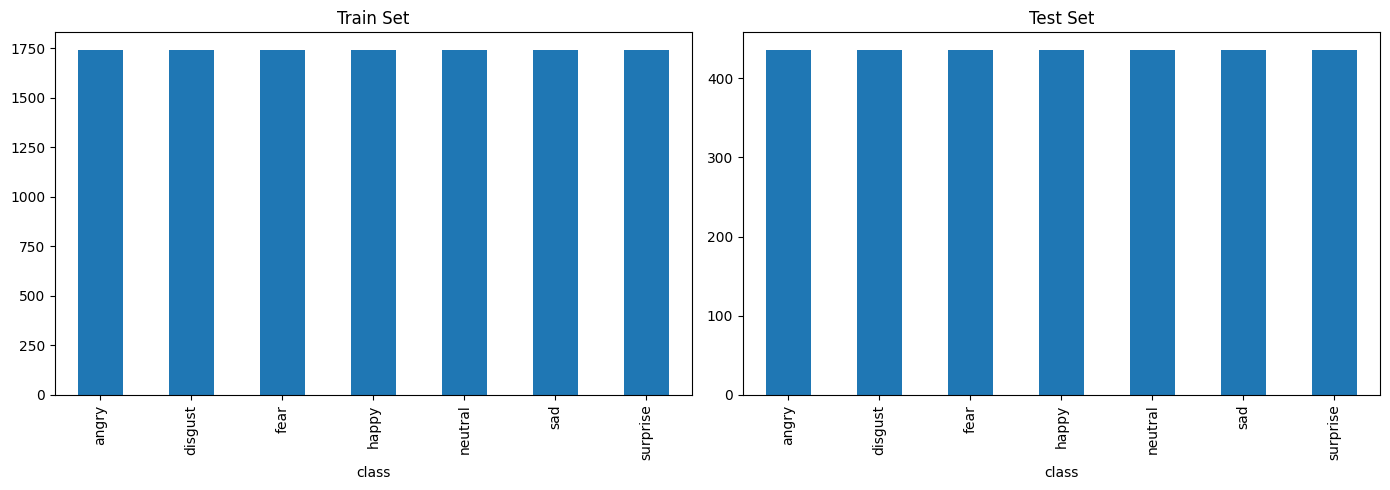

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,5))

train_df["class"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0],
    title="Train Set"
)

test_df["class"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax[1],
    title="Test Set"
)

plt.tight_layout()
plt.show()

In [27]:
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Saved Successfully!")

Saved Successfully!
